In [1]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

# Confirm our image folders exist
data_dir = '../data/raw/archive'
print(os.listdir(data_dir))

PyTorch version: 2.13.0+cpu
Torchvision version: 0.28.0+cpu
['bleached_corals', 'healthy_corals']


In [2]:
from torchvision import transforms

# Standard ImageNet normalization (since we'll use a pretrained model)
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

# Training transforms: includes augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize
])

# Validation/test transforms: no augmentation, just resize + normalize
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

print("Transforms defined successfully")

Transforms defined successfully


In [3]:
from torchvision import datasets

full_dataset = datasets.ImageFolder(root='../data/raw/archive', transform=eval_transforms)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class to index mapping:", full_dataset.class_to_idx)

Total images: 923
Classes: ['bleached_corals', 'healthy_corals']
Class to index mapping: {'bleached_corals': 0, 'healthy_corals': 1}


In [4]:
from torch.utils.data import random_split, Subset
import torch

# Set seed for reproducibility
torch.manual_seed(42)

# Split indices: 70% train, 15% val, 15% test
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

print("Train size:", len(train_subset))
print("Validation size:", len(val_subset))
print("Test size:", len(test_subset))

Train size: 646
Validation size: 138
Test size: 139


In [5]:
# Create separate dataset objects with appropriate transforms
train_dataset = datasets.ImageFolder(root='../data/raw/archive', transform=train_transforms)
eval_dataset = datasets.ImageFolder(root='../data/raw/archive', transform=eval_transforms)

# Use the same indices from our split, but with the right transform applied
train_data = Subset(train_dataset, train_subset.indices)
val_data = Subset(eval_dataset, val_subset.indices)
test_data = Subset(eval_dataset, test_subset.indices)

print("Final train/val/test sizes:", len(train_data), len(val_data), len(test_data))

Final train/val/test sizes: 646 138 139


In [6]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 41
Number of validation batches: 9
Number of test batches: 9


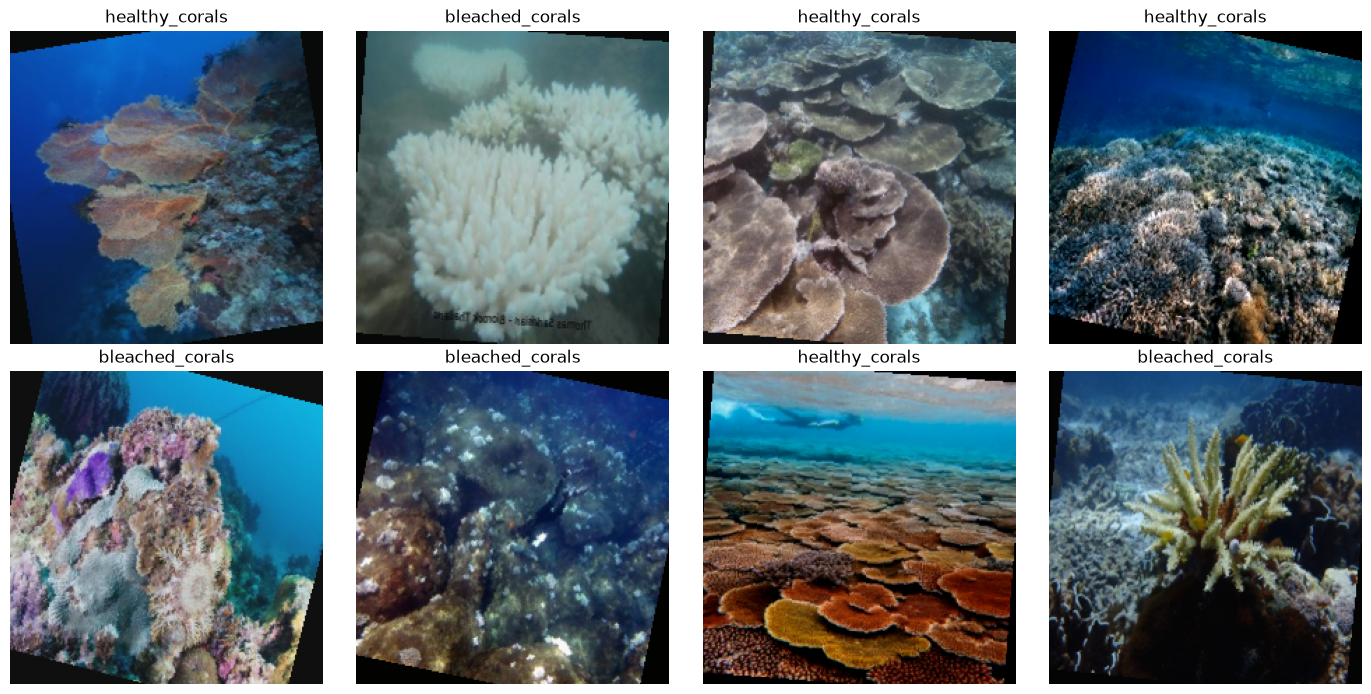

In [7]:
import numpy as np

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Get one batch from training data
images, labels = next(iter(train_loader))

class_names = full_dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(denormalize(images[i]))
        ax.set_title(class_names[labels[i]])
        ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
import torch.nn as nn
from torchvision import models

# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Freeze all the pretrained layers (we won't retrain these)
for param in model.parameters():
    param.requires_grad = False

# Replace the final classifier layer with one suited to our 2-class problem
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)  # 2 classes: bleached, healthy

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [9]:
import torch.optim as optim

# Loss function for classification
criterion = nn.CrossEntropyLoss()

# Only optimize the new classifier layer (everything else is frozen)
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Use CPU since we don't have a GPU
device = torch.device('cpu')
model = model.to(device)

print("Training setup complete. Device:", device)

Training setup complete. Device: cpu


In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=1):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            print(f"  Batch {batch_idx+1}/{len(train_loader)} processed")
        
        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

train_model(model, train_loader, val_loader, criterion, optimizer, epochs=1)

  Batch 1/41 processed
  Batch 2/41 processed
  Batch 3/41 processed
  Batch 4/41 processed
  Batch 5/41 processed
  Batch 6/41 processed
  Batch 7/41 processed
  Batch 8/41 processed
  Batch 9/41 processed
  Batch 10/41 processed
  Batch 11/41 processed
  Batch 12/41 processed
  Batch 13/41 processed
  Batch 14/41 processed
  Batch 15/41 processed
  Batch 16/41 processed
  Batch 17/41 processed
  Batch 18/41 processed
  Batch 19/41 processed
  Batch 20/41 processed
  Batch 21/41 processed
  Batch 22/41 processed
  Batch 23/41 processed
  Batch 24/41 processed
  Batch 25/41 processed
  Batch 26/41 processed
  Batch 27/41 processed
  Batch 28/41 processed
  Batch 29/41 processed
  Batch 30/41 processed
  Batch 31/41 processed
  Batch 32/41 processed
  Batch 33/41 processed
  Batch 34/41 processed
  Batch 35/41 processed
  Batch 36/41 processed
  Batch 37/41 processed
  Batch 38/41 processed
  Batch 39/41 processed
  Batch 40/41 processed
  Batch 41/41 processed
Epoch 1/1 | Train Loss: 0

In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)
        
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = 100 * val_correct / val_total
        val_loss = val_loss / len(val_loader)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)

Epoch 1/5 | Train Loss: 0.4538, Train Acc: 77.55% | Val Loss: 0.5152, Val Acc: 74.64%
Epoch 2/5 | Train Loss: 0.4451, Train Acc: 79.57% | Val Loss: 0.5235, Val Acc: 71.74%
Epoch 3/5 | Train Loss: 0.4197, Train Acc: 80.34% | Val Loss: 0.5051, Val Acc: 73.91%
Epoch 4/5 | Train Loss: 0.4134, Train Acc: 79.88% | Val Loss: 0.5138, Val Acc: 75.36%
Epoch 5/5 | Train Loss: 0.4323, Train Acc: 80.80% | Val Loss: 0.5181, Val Acc: 74.64%


In [13]:
# Unfreeze the last few layers of the feature extractor for fine-tuning
for param in model.features[-3:].parameters():
    param.requires_grad = True

# Use a lower learning rate now, since we're fine-tuning pretrained weights
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

print("Unfrozen last 3 feature blocks. Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Unfrozen last 3 feature blocks. Trainable parameters: 1208642


In [14]:
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)

Epoch 1/5 | Train Loss: 0.4286, Train Acc: 80.19% | Val Loss: 0.5176, Val Acc: 74.64%
Epoch 2/5 | Train Loss: 0.3895, Train Acc: 84.21% | Val Loss: 0.5018, Val Acc: 76.81%
Epoch 3/5 | Train Loss: 0.3496, Train Acc: 86.53% | Val Loss: 0.5111, Val Acc: 77.54%
Epoch 4/5 | Train Loss: 0.3300, Train Acc: 86.22% | Val Loss: 0.5231, Val Acc: 73.91%
Epoch 5/5 | Train Loss: 0.3240, Train Acc: 85.76% | Val Loss: 0.5037, Val Acc: 78.26%


In [16]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total
print(f"Final Test Accuracy: {test_acc:.2f}%")

Final Test Accuracy: 71.94%


In [17]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    normalize
])

# Rebuild datasets with new transforms
train_dataset = datasets.ImageFolder(root='../data/raw/archive', transform=train_transforms)
train_data = Subset(train_dataset, train_subset.indices)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)

print("Stronger augmentation applied")

Stronger augmentation applied


In [18]:
# Reload a fresh pretrained model to start clean
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)

# Unfreeze last 4 blocks this time (slightly more than before)
for param in model.features[-4:].parameters():
    param.requires_grad = True

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 1528642


In [19]:
def train_model_v2(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    best_val_acc = 0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)

        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        val_loss = val_loss / len(val_loader)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '../models/best_coral_model.pth')

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

    print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

train_model_v2(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10)

Epoch 1/10 | Train Loss: 0.5697, Train Acc: 69.35% | Val Loss: 0.5024, Val Acc: 77.54% | LR: 0.000500
Epoch 2/10 | Train Loss: 0.4545, Train Acc: 80.50% | Val Loss: 0.4765, Val Acc: 78.26% | LR: 0.000500
Epoch 3/10 | Train Loss: 0.4235, Train Acc: 80.80% | Val Loss: 0.4338, Val Acc: 83.33% | LR: 0.000500
Epoch 4/10 | Train Loss: 0.3555, Train Acc: 84.52% | Val Loss: 0.5075, Val Acc: 81.88% | LR: 0.000500
Epoch 5/10 | Train Loss: 0.3351, Train Acc: 85.60% | Val Loss: 0.5368, Val Acc: 80.43% | LR: 0.000250
Epoch 6/10 | Train Loss: 0.2726, Train Acc: 88.08% | Val Loss: 0.4777, Val Acc: 81.88% | LR: 0.000250
Epoch 7/10 | Train Loss: 0.2673, Train Acc: 89.78% | Val Loss: 0.5899, Val Acc: 81.88% | LR: 0.000250
Epoch 8/10 | Train Loss: 0.2012, Train Acc: 91.49% | Val Loss: 0.5510, Val Acc: 80.43% | LR: 0.000250
Epoch 9/10 | Train Loss: 0.2180, Train Acc: 91.33% | Val Loss: 0.6406, Val Acc: 80.43% | LR: 0.000250
Epoch 10/10 | Train Loss: 0.2177, Train Acc: 90.09% | Val Loss: 0.5152, Val Acc: 8

In [20]:
# Load the best saved model
best_model = models.mobilenet_v2(weights=None)
num_features = best_model.classifier[1].in_features
best_model.classifier[1] = nn.Linear(num_features, 2)
best_model.load_state_dict(torch.load('../models/best_coral_model.pth'))
best_model = best_model.to(device)
best_model.eval()

# Evaluate on test set
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total
print(f"Final Test Accuracy (best checkpoint): {test_acc:.2f}%")

Final Test Accuracy (best checkpoint): 75.54%
